### Instalação Pacotes caso não reconheça os instalados em requeriments

In [ ]:
pip install geopandas matplotlib mapclassify

Note: you may need to restart the kernel to use updated packages.


### CONEXÃO COM A TABELA DO DBT

In [ ]:
import duckdb
import pandas as pd
import os

DB_PATH = 'dbt_project/data/censo_escolar.duckdb'

if not os.path.exists(DB_PATH):
    print(f"❌ Arquivo não encontrado!")
else:
    con = duckdb.connect(DB_PATH, read_only=True)
    
    # Corrigido: Sem espaços entre as vírgulas
    con.execute("SET search_path='main_refined,main_staging,main'")
    
    # Agora o select vai funcionar direto
    df = con.execute("SELECT * FROM refined_censo_escolar").df()
    
    pd.set_option('display.max_columns', None)
    print(f"✅ Sucesso! {len(df)} linhas carregadas.")
    display(df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Sucesso! 180540 linhas carregadas.


,CO_ENTIDADE,NU_ANO_CENSO,SG_UF,NO_MUNICIPIO,CO_MUNICIPIO,NO_REGIAO,dependencia_adm,localizacao,possui_internet,internet_alunos,possui_banda_larga,possui_computador,acesso_internet_computador,internet_aprendizagem,internet_comunidade,laboratorio_informatica,possui_desktop_aluno,possui_portatil_aluno,possui_tablet_aluno,IN_INTERNET,IN_INTERNET_ALUNOS,IN_EQUIP_LOUSA_DIGITAL,IN_INTERNET_APRENDIZAGEM,perfil_uso_tecnologico,QT_DESKTOP_ALUNO,QT_COMP_PORTATIL_ALUNO,QT_TABLET_ALUNO,QT_EQUIP_LOUSA_DIGITAL,QT_MAT_BAS,QT_MAT_FUND,QT_MAT_FUND_D,QT_MAT_FUND_N,QT_MAT_MED,QT_MAT_MED_D,QT_MAT_MED_N,QT_MAT_BAS_FEM,QT_MAT_BAS_MASC,QT_MAT_BAS_ND,QT_MAT_BAS_BRANCA,QT_MAT_BAS_PRETA,QT_MAT_BAS_PARDA,QT_MAT_BAS_AMARELA,QT_MAT_BAS_INDIGENA,QT_MAT_ZR_URB,QT_MAT_ZR_RUR,QT_DOC_BAS,QT_DOC_FUND,QT_DOC_MED,QT_DOC_BAS_DISC_INFO_COMPUTACAO,QT_DOC_BAS_ESPEC_EDUC_TIC,matricula_fund_med,pct_alunos_diurno,pct_alunos_noturno,pct_alunos_fund,pct_alunos_medio,docente_fund_med,pct_docentes_fund,pct_docentes_med,proporcao_alunos_por_docente,pct_alunos_brasil_preta_parda,total_dispositivos_aluno,densidade_tecnologica_total,densidade_tecnologica_diurno,densidade_tecnologica_noturno,pct_densidade_tecnologica_total,proporcao_docentes_especialista_tic
0,31382019,2025,MG,Brasilândia de Minas,3108552,Sudeste,Municipal,Urbana,Sim,Não,Sim,Sim,Não,Sim,Não,Não,Sim,Sim,Não,1,0,0,1,Conectividade Pedagogica Plena,1,1,0,0,67,0,0,0,0,0,0,26,41,0,14,4,49,0,0,67,0,4,0,0,0,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,79.10,2,NaN,NaN,NaN,NaN,0.0
1,31382027,2025,MG,Brasilândia de Minas,3108552,Sudeste,Municipal,Urbana,Sim,Não,Sim,Sim,Não,Não,Não,Não,Sim,Não,Não,1,0,0,0,Internet Apenas Administrativa,2,0,0,0,61,0,0,0,0,0,0,32,29,4,12,4,39,2,0,61,0,2,0,0,0,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,70.49,2,NaN,NaN,NaN,NaN,0.0
2,31079561,2025,MG,Brasília de Minas,3108602,Sudeste,Estadual,Urbana,Sim,Sim,Sim,Sim,Sim,Sim,Não,Sim,Sim,Sim,Não,1,1,0,1,Conectividade Pedagogica Plena,35,16,0,0,305,184,184,0,79,79,0,149,156,3,52,16,233,1,0,296,9,25,16,17,0,0,263,100.0,0.0,69.96,30.04,33,48.48,51.52,7.97,81.64,51,19.39,19.39,NaN,19.39,0.0
3,31079570,2025,MG,Brasília de Minas,3108602,Sudeste,Estadual,Urbana,Sim,Sim,Sim,Sim,Sim,Sim,Não,Sim,Sim,Sim,Não,1,1,1,1,Conectividade Pedagogica Plena,59,4,0,1,283,283,283,0,0,0,0,133,150,0,52,11,216,4,0,262,21,19,19,0,0,0,283,100.0,0.0,100.00,0.00,19,100.00,0.00,14.89,80.21,64,22.61,22.61,NaN,22.61,0.0
4,31079588,2025,MG,Brasília de Minas,3108602,Sudeste,Estadual,Urbana,Sim,Sim,Sim,Sim,Sim,Sim,Não,Sim,Não,Sim,Sim,1,1,1,1,Conectividade Pedagogica Plena,0,10,2,1,1075,481,481,0,0,0,0,619,456,22,178,75,792,8,0,817,258,55,30,0,0,0,481,100.0,0.0,100.00,0.00,30,100.00,0.00,16.03,80.65,13,2.70,2.70,NaN,2.70,0.0


In [ ]:
import pandas as pd

# 1. Configura o pandas para exibir todas as linhas do output sem pular nada
pd.set_option('display.max_rows', None)

# 2. Executa o DESCRIBE novamente
colunas = con.execute("DESCRIBE refined_censo_escolar").df()
print(colunas[['column_name', 'column_type']].to_string())

# 3. Reseta as configurações do pandas para o padrão (Corrigido aqui!)
pd.reset_option('display.max_rows')

                            column_name column_type
0                           CO_ENTIDADE      BIGINT
1                          NU_ANO_CENSO      BIGINT
2                                 SG_UF     VARCHAR
3                          NO_MUNICIPIO     VARCHAR
4                          CO_MUNICIPIO      BIGINT
5                             NO_REGIAO     VARCHAR
6                       dependencia_adm     VARCHAR
7                           localizacao     VARCHAR
8                       possui_internet     VARCHAR
9                       internet_alunos     VARCHAR
10                   possui_banda_larga     VARCHAR
11                    possui_computador     VARCHAR
12           acesso_internet_computador     VARCHAR
13                internet_aprendizagem     VARCHAR
14                  internet_comunidade     VARCHAR
15              laboratorio_informatica     VARCHAR
16                 possui_desktop_aluno     VARCHAR
17                possui_portatil_aluno     VARCHAR
18          

In [ ]:
# Esse loop ignora as travas visuais do VS Code/Jupyter
colunas = con.execute("DESCRIBE refined_censo_escolar").df()

for idx, row in colunas.iterrows():
    print(f"{idx}: {row['column_name']} ({row['column_type']})")

0: CO_ENTIDADE (BIGINT)
1: NU_ANO_CENSO (BIGINT)
2: SG_UF (VARCHAR)
3: NO_MUNICIPIO (VARCHAR)
4: CO_MUNICIPIO (BIGINT)
5: NO_REGIAO (VARCHAR)
6: dependencia_adm (VARCHAR)
7: localizacao (VARCHAR)
8: possui_internet (VARCHAR)
9: internet_alunos (VARCHAR)
10: possui_banda_larga (VARCHAR)
11: possui_computador (VARCHAR)
12: acesso_internet_computador (VARCHAR)
13: internet_aprendizagem (VARCHAR)
14: internet_comunidade (VARCHAR)
15: laboratorio_informatica (VARCHAR)
16: possui_desktop_aluno (VARCHAR)
17: possui_portatil_aluno (VARCHAR)
18: possui_tablet_aluno (VARCHAR)
19: IN_INTERNET (BIGINT)
20: IN_INTERNET_ALUNOS (BIGINT)
21: IN_EQUIP_LOUSA_DIGITAL (BIGINT)
22: IN_INTERNET_APRENDIZAGEM (BIGINT)
23: perfil_uso_tecnologico (VARCHAR)
24: QT_DESKTOP_ALUNO (BIGINT)
25: QT_COMP_PORTATIL_ALUNO (BIGINT)
26: QT_TABLET_ALUNO (BIGINT)
27: QT_EQUIP_LOUSA_DIGITAL (BIGINT)
28: QT_MAT_BAS (BIGINT)
29: QT_MAT_FUND (BIGINT)
30: QT_MAT_FUND_D (BIGINT)
31: QT_MAT_FUND_N (BIGINT)
32: QT_MAT_MED (BIGINT)
3

In [ ]:
colunas = con.execute("DESCRIBE refined_censo_escolar").df()

# Filtrando para mostrar apenas as colunas que têm "laboratorio" ou "informatica" no nome
resultado = colunas[colunas['column_name'].str.contains('laboratorio|informatica', case=False, na=False)]

print("--- Colunas Encontradas ---")
print(resultado[['column_name', 'column_type']].to_string())

--- Colunas Encontradas ---
                column_name column_type
15  laboratorio_informatica     VARCHAR


In [ ]:
# Executar para ver a estrutura real da tabela
colunas = con.execute("DESCRIBE refined_censo_escolar").df()
print(colunas[['column_name', 'column_type']].to_string())

                            column_name column_type
0                           CO_ENTIDADE      BIGINT
1                          NU_ANO_CENSO      BIGINT
2                                 SG_UF     VARCHAR
3                          NO_MUNICIPIO     VARCHAR
4                          CO_MUNICIPIO      BIGINT
5                             NO_REGIAO     VARCHAR
6                       dependencia_adm     VARCHAR
7                           localizacao     VARCHAR
8                       possui_internet     VARCHAR
9                       internet_alunos     VARCHAR
10                   possui_banda_larga     VARCHAR
11                    possui_computador     VARCHAR
12           acesso_internet_computador     VARCHAR
13                internet_aprendizagem     VARCHAR
14                  internet_comunidade     VARCHAR
15              laboratorio_informatica     VARCHAR
16                 possui_desktop_aluno     VARCHAR
17                possui_portatil_aluno     VARCHAR
18          

In [17]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. CONEXÃO E EXTRAÇÃO (AGORA COM TODAS AS COLUNAS!)
con = duckdb.connect('dbt_project/data/censo_escolar.duckdb', read_only=True)
con.execute("SET search_path='main_refined,main_staging,main'")

# Adicionei no SELECT as colunas que estavam faltando no seu erro
df = con.execute("""
    SELECT 
        CO_ENTIDADE,
        NO_MUNICIPIO,
        SG_UF,
        NO_REGIAO,
        dependencia_adm,
        IN_INTERNET_ALUNOS,
        IN_INTERNET_APRENDIZAGEM,     -- Adicionado
        IN_LABORATORIO_INFORMATICA,
        densidade_tecnologica_total,
        QT_EQUIP_LOUSA_DIGITAL,
        proporcao_docentes_especialista_tic, -- Adicionado
        pct_alunos_brasil_preta_parda
    FROM refined_censo_escolar
""").df()

# 2. PREPARAÇÃO PARA O PCA
# Agora a lista de features vai encontrar as colunas no 'df'
features = [
    'IN_INTERNET_ALUNOS', 
    'IN_INTERNET_APRENDIZAGEM', 
    'IN_LABORATORIO_INFORMATICA', 
    'densidade_tecnologica_total', 
    'QT_EQUIP_LOUSA_DIGITAL',
    'proporcao_docentes_especialista_tic'
]

# 3. TRATAMENTO E PADRONIZAÇÃO
x = df[features].fillna(0) 

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 4. EXECUÇÃO DO PCA
pca = PCA(n_components=1) 
df['SMED_raw'] = pca.fit_transform(x_scaled)

# 5. NORMALIZAÇÃO DO SCORE (0 a 100)
min_val = df['SMED_raw'].min()
max_val = df['SMED_raw'].max()
df['SMED'] = ((df['SMED_raw'] - min_val) / (max_val - min_val)) * 100

# 6. RESULTADO FINAL
print(f"Variância explicada pelo SMED: {pca.explained_variance_ratio_[0]*100:.2f}%")
display(df[['NO_MUNICIPIO', 'SG_UF', 'SMED']].sample(10)) # Sample é melhor que head para ver o Brasil todo!

BinderException: Binder Error: Referenced column "IN_LABORATORIO_INFORMATICA" not found in FROM clause!
Candidate bindings: "QT_DOC_BAS_DISC_INFO_COMPUTACAO", "IN_INTERNET_ALUNOS", "IN_INTERNET", "IN_INTERNET_APRENDIZAGEM", "NO_REGIAO"

LINE 10:         IN_LABORATORIO_INFORMATICA,
                 ^

In [ ]:
# Ver o total de linhas e colunas
print(f"Total de escolas processadas: {df.shape[0]}")

# Ver uma amostra aleatória de 10 escolas (para sair de Tonantins)
display(df.sample(10))

Total de escolas processadas: 180540


,CO_ENTIDADE,NU_ANO_CENSO,SG_UF,NO_MUNICIPIO,CO_MUNICIPIO,NO_REGIAO,dependencia_adm,localizacao,possui_internet,internet_alunos,possui_banda_larga,possui_computador,acesso_internet_computador,internet_aprendizagem,internet_comunidade,laboratorio_informatica,possui_desktop_aluno,possui_portatil_aluno,possui_tablet_aluno,IN_INTERNET,IN_INTERNET_ALUNOS,IN_EQUIP_LOUSA_DIGITAL,IN_INTERNET_APRENDIZAGEM,perfil_uso_tecnologico,QT_DESKTOP_ALUNO,QT_COMP_PORTATIL_ALUNO,QT_TABLET_ALUNO,QT_EQUIP_LOUSA_DIGITAL,QT_MAT_BAS,QT_MAT_FUND,QT_MAT_FUND_D,QT_MAT_FUND_N,QT_MAT_MED,QT_MAT_MED_D,QT_MAT_MED_N,QT_MAT_BAS_FEM,QT_MAT_BAS_MASC,QT_MAT_BAS_ND,QT_MAT_BAS_BRANCA,QT_MAT_BAS_PRETA,QT_MAT_BAS_PARDA,QT_MAT_BAS_AMARELA,QT_MAT_BAS_INDIGENA,QT_MAT_ZR_URB,QT_MAT_ZR_RUR,QT_DOC_BAS,QT_DOC_FUND,QT_DOC_MED,QT_DOC_BAS_DISC_INFO_COMPUTACAO,QT_DOC_BAS_ESPEC_EDUC_TIC,matricula_fund_med,pct_alunos_diurno,pct_alunos_noturno,pct_alunos_fund,pct_alunos_medio,docente_fund_med,pct_docentes_fund,pct_docentes_med,proporcao_alunos_por_docente,pct_alunos_brasil_preta_parda,total_dispositivos_aluno,densidade_tecnologica_total,densidade_tecnologica_diurno,densidade_tecnologica_noturno,pct_densidade_tecnologica_total,proporcao_docentes_especialista_tic
27672,52105024,2025,GO,Anápolis,5201108,Centro-Oeste,Municipal,Urbana,Sim,Não,Sim,Sim,Não,Não,Não,Não,Não,Não,Não,1,0,0,0,Internet Apenas Administrativa,0,0,0,0,209,0,0,0,0,0,0,109,100,1,59,13,135,1,0,203,6,8,0,0,0,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,70.81,0,NaN,NaN,NaN,NaN,0.0
159801,50013181,2025,MS,Batayporã,5002001,Centro-Oeste,Estadual,Urbana,Sim,Sim,Sim,Sim,Sim,Sim,Não,Sim,Sim,Sim,Não,1,1,0,1,Conectividade Pedagogica Plena,3,20,0,0,504,504,504,0,0,0,0,262,242,17,172,9,304,2,0,486,18,24,24,0,0,0,504,100.00,0.00,100.00,0.00,24,100.00,0.00,21.00,62.10,23,4.56,4.56,NaN,4.56,0.0
124242,35440644,2025,SP,Jundiaí,3525904,Sudeste,Privada,Urbana,Sim,Não,Sim,Sim,Não,Não,Não,Não,Sim,Não,Não,1,0,0,0,Internet Apenas Administrativa,1,0,0,0,23,0,0,0,0,0,0,16,7,6,16,0,1,0,0,23,0,2,0,0,0,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,4.35,1,NaN,NaN,NaN,NaN,0.0
49856,41064372,2025,PR,Formosa do Oeste,4108205,Sul,Estadual,Urbana,Sim,Sim,Sim,Sim,Sim,Sim,Sim,Sim,Sim,Sim,Sim,1,1,1,1,Conectividade Pedagogica Plena,39,57,12,1,166,140,140,0,26,26,0,84,82,0,114,1,50,0,1,138,28,34,28,23,0,0,166,100.00,0.00,84.34,15.66,51,54.90,45.10,3.25,30.72,109,65.66,65.66,NaN,65.66,0.0
471,31283185,2025,MG,Canápolis,3111804,Sudeste,Municipal,Urbana,Sim,Não,Sim,Sim,Não,Sim,Não,Não,Não,Não,Não,1,0,0,1,Conexao Sem Dispositivos,0,0,0,0,192,0,0,0,0,0,0,84,108,0,103,4,84,1,0,192,0,20,0,0,0,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,45.83,0,NaN,NaN,NaN,NaN,0.0
57715,42001293,2025,SC,Florianópolis,4205407,Sul,Estadual,Urbana,Sim,Não,Sim,Sim,Não,Não,Não,Não,Sim,Não,Sim,1,0,1,0,Internet Apenas Administrativa,3,0,20,1,138,138,138,0,0,0,0,63,75,16,79,14,29,0,0,137,1,12,12,0,0,0,138,100.00,0.00,100.00,0.00,12,100.00,0.00,11.50,31.16,24,17.39,17.39,NaN,17.39,0.0
92240,26188716,2025,PE,Paulista,2610707,Nordeste,Municipal,Urbana,Sim,Sim,Sim,Sim,Sim,Sim,Não,Não,Não,Sim,Sim,1,1,0,1,Conectividade Pedagogica Plena,0,3,1,0,145,107,107,0,0,0,0,76,69,0,32,19,94,0,0,142,3,8,6,0,0,0,107,100.00,0.00,100.00,0.00,6,100.00,0.00,17.83,77.93,4,3.74,3.74,NaN,3.74,0.0
134010,15529177,2025,PA,Limoeiro do Ajuru,1504000,Norte,Municipal,Rural,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,1,0,0,0,Internet Apenas Administrativa,0,0,0,0,150,106,106,0,0,0,0,69,81,0,7,1,142,0,0,4,146,17,12,0,0,0,106,100.00,0.00,100.00,0.00,12,100.00,0.00,8.83,95.33,0,0.00,0.00,NaN,0.00,0.0
85475,13013181,2025,AM,Tefé,1304203,Norte,Municipal,Rural,Sim,Não,Sim,Não,Não,Sim,Não,Não,Não,Não,Não,1,0,0,1,Conexao Sem Dispositivos,0,0,0,0,69,46,46,0,0,0,0,32,37,0,0,0,5,0,64,0,69,7,6,0,0,0,46,100.00,0.00,100.00,0.00,6,100.00,0.00,7.67,7.25,0,0.00,0.00,NaN,0.00,0.0
97902,31033634,2025,MG,Igaratinga,3130200,Sudeste,Estadual,Urbana,Sim,Não,Sim,Sim,Não,Sim,Não,Sim,Sim,Sim,Sim,1,0,1,1,Conectividade Pedagogica Plena,42,6,15,1,345,199,199,0,146,27,119,159,186

In [ ]:
df_comparacao = df[df['SG_UF'].isin(['AM', 'SP'])]
display(df_comparacao.groupby('SG_UF')['SMED'].mean())

KeyError: 'Column not found: SMED'

In [ ]:
# Verifique se o SMED médio bate com o Perfil que você criou no SQL
print(df.groupby('perfil_uso_tecnologico')['SMED'].mean().sort_values())

In [ ]:
# Transformando o SMED em uma escala de 0 a 100
df['SMED_FINAL'] = ((df['SMED'] - df['SMED'].min()) / (df['SMED'].max() - df['SMED'].min())) * 100

# Verificando a nova média por Estado
print(df.groupby('SG_UF')['SMED_FINAL'].mean().sort_values(ascending=False))

SG_UF
SC    0.547910
RS    0.525236
RO    0.512865
SE    0.479728
MT    0.479047
PR    0.461546
MS    0.437665
SP    0.433550
GO    0.432507
ES    0.431119
MG    0.405813
TO    0.397616
RN    0.395722
RJ    0.378766
CE    0.366883
PE    0.341472
DF    0.321314
BA    0.319959
AL    0.309484
PI    0.270162
PB    0.260901
RR    0.258403
PA    0.245360
AP    0.192044
MA    0.189633
AM    0.155278
AC    0.138587
Name: SMED_FINAL, dtype: float64


/tmp/ipykernel_7480/412789595.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Variavel', data=loadings, palette='viridis')


                              Variavel      Peso
0                   IN_INTERNET_ALUNOS  0.703401
2  proporcao_docentes_especialista_tic  0.670183
1          densidade_tecnologica_total  0.236814


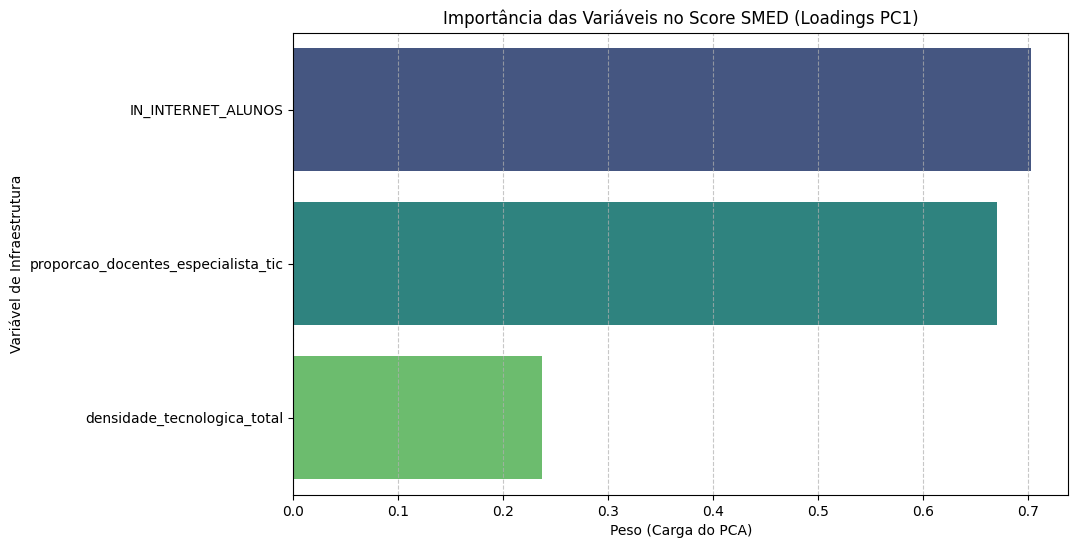

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definindo as variáveis baseadas no seu novo SQL
# Certifique-se de que estas colunas existem no seu DataFrame
features_smed = [
    'IN_INTERNET_ALUNOS','densidade_tecnologica_total','proporcao_docentes_especialista_tic'
    # Se você quiser adicionar as flags de laboratório e aprendizagem, 
    # elas precisam ser numéricas (0 ou 1)
]

# 2. Preparando os dados
x = df[features_smed].fillna(0)
x_scaled = StandardScaler().fit_transform(x)

# 3. PCA
pca = PCA(n_components=1)
pca.fit(x_scaled)

# 4. Extraindo as Cargas (Weights)
loadings = pd.DataFrame({
    'Variavel': features_smed,
    'Peso': pca.components_[0]
}).sort_values(by='Peso', ascending=False)

# 5. Gerando o Gráfico de Importância
plt.figure(figsize=(10, 6))
sns.barplot(x='Peso', y='Variavel', data=loadings, palette='viridis')
plt.title('Importância das Variáveis no Score SMED (Loadings PC1)')
plt.xlabel('Peso (Carga do PCA)')
plt.ylabel('Variável de Infraestrutura')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('pesos_smed.png')
print(loadings)

Mapa de Coropletas (onde o município muda de cor)

In [ ]:
import plotly.express as px

# Agrupando por município para o mapa não travar
df_mapa = df.groupby(['NO_MUNICIPIO', 'SG_UF', 'idhm']).agg({
    'SMED': 'mean',
    'pct_alunos_brasil_preta_parda': 'mean'
}).reset_index()

# Criando o gráfico de dispersão com "bolhas" (o tamanho da bolha é a exclusão)
fig = px.scatter(df_mapa, 
                 x="idhm", 
                 y="SMED", 
                 size="pct_alunos_brasil_preta_parda", 
                 color="SG_UF",
                 hover_name="NO_MUNICIPIO",
                 title="Relação IDHM vs Inclusão Digital (SMED) por Município")

fig.show()

ModuleNotFoundError: No module named 'plotly'

idhm 

In [ ]:
# identificando os arquivos que estão na pasta dados_mapa
import os
print(os.listdir('data/dados_mapa'))

['IDHM.dbf', 'IDHM.shp', 'IDHM.xlsx', 'IDHM.qpj', 'IDHM.cpg', 'IDHM.shx', 'IDHM.xlsx:Zone.Identifier', 'IDHM.prj']


In [ ]:
# arquivo shp é onde estão os dados do idhm

import geopandas as gpd
import os

# 1. Ajustado: A pasta 'dados_mapa' está dentro de 'data'
pasta_mapa = 'data/dados_mapa'

# 2. Encontra automaticamente o arquivo .shp lá dentro
arquivos = os.listdir(pasta_mapa)
nome_do_arquivo = [f for f in arquivos if f.endswith('.shp')][0]

# 3. Monta o caminho correto e carrega o mapa
caminho_final = os.path.join(pasta_mapa, nome_do_arquivo)
mapa = gpd.read_file(caminho_final)

print("✅ Mapa carregado com sucesso!")
print("\nColunas encontradas no mapa:")
print(mapa.columns.tolist())

# Mostra as primeiras linhas para checar os dados
display(mapa.head())

✅ Mapa carregado com sucesso!

Colunas encontradas no mapa:
['Cod_ibge', 'Nome', 'Rotulo', 'Area_Km2', 'IDMH', 'IDHM_E', 'IDHM_L', 'IDHM_R', 'geometry']


,Cod_ibge,Nome,Rotulo,Area_Km2,IDMH,IDHM_E,IDHM_L,IDHM_R,geometry
0,3500105,Adamantina,Adamantina,411.987,0.79,0.75,0.85,0.77,"POLYGON ((-51.17735 -21.69213, -51.17716 -21.6..."
1,3500204,Adolfo,Adolfo,211.055,0.73,0.64,0.84,0.71,"POLYGON ((-49.74715 -21.29637, -49.74682 -21.2..."
2,3500303,Aguai,Aguaí,474.554,0.71,0.60,0.85,0.70,"POLYGON ((-47.23298 -22.05409, -47.23289 -22.0..."
3,3500402,Aguas da Prata,Águas da Prata,142.961,0.78,0.71,0.88,0.75,"POLYGON ((-46.75758 -21.84763, -46.7575 -21.84..."
4,3500501,Aguas de Lindoia,Águas de Lindóia,60.126,0.74,0.67,0.84,0.72,"POLYGON ((-46.6602 -22.47948, -46.66018 -22.47..."


In [9]:
import geopandas as gpd

# Carregando o arquivo principal
mapa = gpd.read_file('data/dados_mapa/IDHM.shp')

# Verificando se o código do IBGE e o IDHM aparecem na tabela
print("Colunas do mapa:")
print(mapa.columns.tolist())

# Mostrando as primeiras linhas para confirmar os valores
# display(mapa[['NM_MUNICIP', 'CD_GEOCMU', 'IDHM2010', 'geometry']].head())

Colunas do mapa:
['Cod_ibge', 'Nome', 'Rotulo', 'Area_Km2', 'IDMH', 'IDHM_E', 'IDHM_L', 'IDHM_R', 'geometry']


In [13]:
import geopandas as gpd
import os

# 1. Nome da pasta que você criou dentro do projeto
pasta_mapa = 'data/dados_mapa'

# 2. Comando para o Python listar o que tem lá dentro e achar o arquivo do mapa
arquivos = os.listdir(pasta_mapa)
nome_do_arquivo = [f for f in arquivos if f.endswith('.shp')][0]

# 3. Agora sim, carregar o mapa
caminho_final = os.path.join(pasta_mapa, nome_do_arquivo)
mapa = gpd.read_file(caminho_final)

print("✅ Mapa carregado com sucesso!")
print(mapa.columns.tolist())
display(mapa.head())

✅ Mapa carregado com sucesso!
['Cod_ibge', 'Nome', 'Rotulo', 'Area_Km2', 'IDMH', 'IDHM_E', 'IDHM_L', 'IDHM_R', 'geometry']


,Cod_ibge,Nome,Rotulo,Area_Km2,IDMH,IDHM_E,IDHM_L,IDHM_R,geometry
0,3500105,Adamantina,Adamantina,411.987,0.79,0.75,0.85,0.77,"POLYGON ((-51.17735 -21.69213, -51.17716 -21.6..."
1,3500204,Adolfo,Adolfo,211.055,0.73,0.64,0.84,0.71,"POLYGON ((-49.74715 -21.29637, -49.74682 -21.2..."
2,3500303,Aguai,Aguaí,474.554,0.71,0.60,0.85,0.70,"POLYGON ((-47.23298 -22.05409, -47.23289 -22.0..."
3,3500402,Aguas da Prata,Águas da Prata,142.961,0.78,0.71,0.88,0.75,"POLYGON ((-46.75758 -21.84763, -46.7575 -21.84..."
4,3500501,Aguas de Lindoia,Águas de Lindóia,60.126,0.74,0.67,0.84,0.72,"POLYGON ((-46.6602 -22.47948, -46.66018 -22.47..."
